# Lorenz chaos: close starts, different futures

Inspired by **Lorenz Chaos Explorer**, Juy | AI experiments:
[catalog](https://github.com/magiccreator-ai/awesome-gpt-6-astra#lorenz-chaos-explorer) ·
[creator post](https://x.com/juyeam/status/2096572156453028193) ·
[creator demo](https://tiny-worlds-juyeam.juyeam.chatgpt.site/chaos) ·
[Our 3D attractor](https://jltobias.github.io/JupyterLite-Astra-demos/demos/?scene=chaos).

**Learn:** separate sensitivity to initial conditions from numerical error.
**Predict:** will two very close starts remain close forever in a deterministic model?
The classic Lorenz system is a simplified convection model, not a weather forecast.
We use dimensionless variables and fourth-order Runge–Kutta integration.


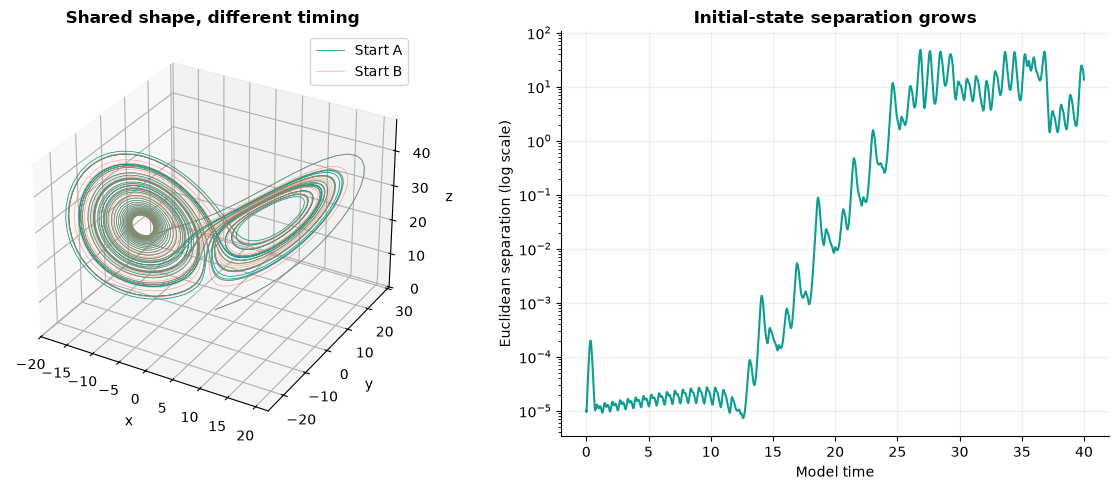

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astra_utils import style, animate_tracks
style()
def lorenz(p,sigma=10,rho=28,beta=8/3):
    x,y,z = p
    return np.array([sigma*(y-x),x*(rho-z)-y,x*y-beta*z])
def integrate(initial,dt=.01,steps=4000):
    out = np.empty((steps+1,3)); out[0] = initial
    for i in range(steps):
        p = out[i]
        k1 = lorenz(p); k2 = lorenz(p+dt*k1/2)
        k3 = lorenz(p+dt*k2/2); k4 = lorenz(p+dt*k3)
        out[i+1] = p+dt*(k1+2*k2+2*k3+k4)/6
    return out
dt = .01
epsilon = 1e-5
a = integrate([1,1,1],dt)
b = integrate([1+epsilon,1,1],dt)
time = np.arange(len(a))*dt
separation = np.linalg.norm(a-b,axis=1)
fig = plt.figure(figsize=(12,5))
ax = fig.add_subplot(121,projection='3d')
ax.plot(*a.T,lw=.6,label='Start A')
ax.plot(*b.T,lw=.5,alpha=.6,label='Start B')
ax.set(title='Shared shape, different timing',xlabel='x',ylabel='y',zlabel='z')
ax.legend()
ax = fig.add_subplot(122)
ax.semilogy(time,separation)
ax.set(title='Initial-state separation grows',xlabel='Model time',ylabel='Euclidean separation (log scale)')
ax.grid(alpha=.2)
fig.tight_layout()
plt.show()


In [2]:
tracks = np.stack((a[::12,[0,2]],b[::12,[0,2]]),axis=1)
animate_tracks(tracks,(-25,25,0,55),'Two trajectories · x/z projection',labels=['Teal: start A','Coral: start B'],dt=dt*12,units='model time')


Interactive animation: run this cell in JupyterLite to play or scrub.

**Read the plots:** both trajectories visit the same two-lobed region, yet their moment-by-moment
positions diverge. Log scale reveals growth across orders of magnitude. Growth does not continue
forever: the trajectories stay within a bounded region. Do not infer a precise Lyapunov exponent
by fitting the entire curve, including transients and saturation.


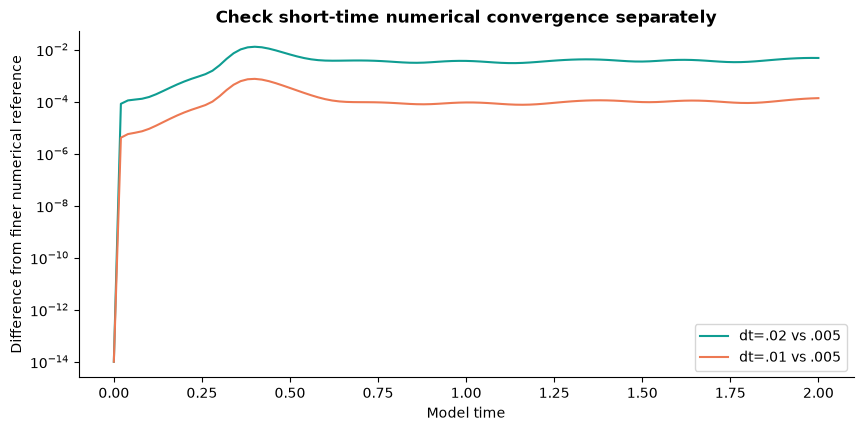

In [3]:
coarse = integrate([1,1,1],dt=.02,steps=100)
fine = integrate([1,1,1],dt=.01,steps=200)[::2]
finer = integrate([1,1,1],dt=.005,steps=400)[::4]
error_coarse = np.linalg.norm(coarse-finer,axis=1)
error_fine = np.linalg.norm(fine-finer,axis=1)
plt.semilogy(np.linspace(0,2,101),np.maximum(error_coarse,1e-14),label='dt=.02 vs .005')
plt.semilogy(np.linspace(0,2,101),np.maximum(error_fine,1e-14),label='dt=.01 vs .005')
plt.xlabel('Model time')
plt.ylabel('Difference from finer numerical reference')
plt.title('Check short-time numerical convergence separately')
plt.legend()
plt.show()
assert np.isfinite(a).all() and np.isfinite(b).all()
assert error_fine[-1] < error_coarse[-1]


**Experiment:** change `epsilon` by a factor of ten. Then change `dt` independently.
Explain why these are two different experiments. The finer solution is a numerical reference,
not exact truth; good short-time convergence does not guarantee a specific long-term trajectory.
